In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn yfinance tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 8.1 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snspi

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import yfinance as yf

### Data Collection ( Real Stock Data)

#### We use Yahoo Finance API

In [5]:
stock= yf.download("AAPL", start="2020-01-01", end="2025-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [6]:
stock

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200
...,...,...,...,...,...
2024-12-24,256.797241,256.807166,253.903032,254.101958,23234700
2024-12-26,257.612701,258.686851,256.230269,256.787224,27237100


#### Plot closing price

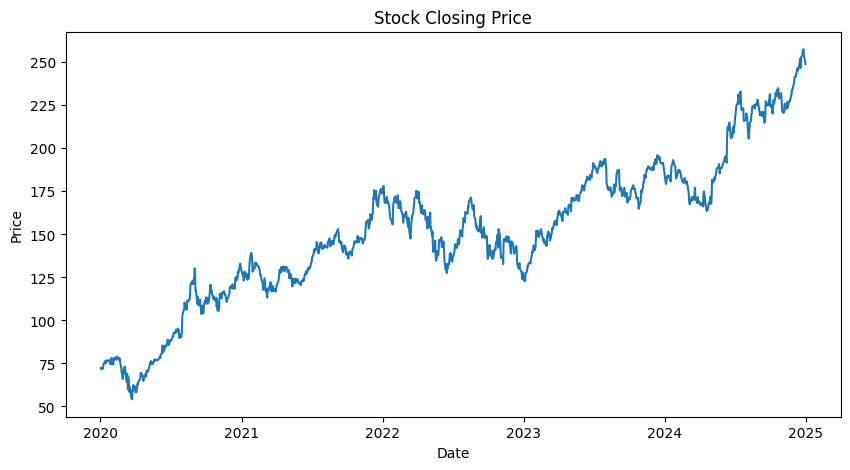

In [7]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

#### Plot price closing low to high

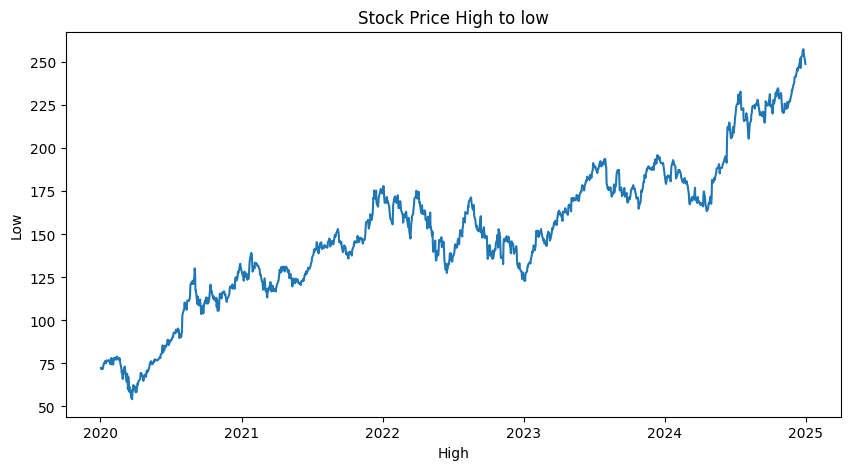

In [8]:
plt.figure(figsize=(10,5))
plt.plot(stock['Close'])
plt.title("Stock Price High to low")
plt.xlabel("High")
plt.ylabel("Low")
plt.show()

### Data Processing

In [9]:
X = stock[['Open','High','Low','Volume']]
y = stock['Close']

#### Train-Test Split

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, shuffle=False)

#### Important: shuffle=False because stock data is time-series.

#### Linear Regression model

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Prediction

In [12]:
y_pred = model.predict(X_test)

In [13]:
# Egnore, the reason comming error is the data of row not same or equal
print(len(stock))
print(len(y))
print(len(y_pred))


1258
1258
252


#### Model Evaluation

In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 1.1613887862775554
R2 Score: 0.9982174187442311


#### Actual vs Predicted plot

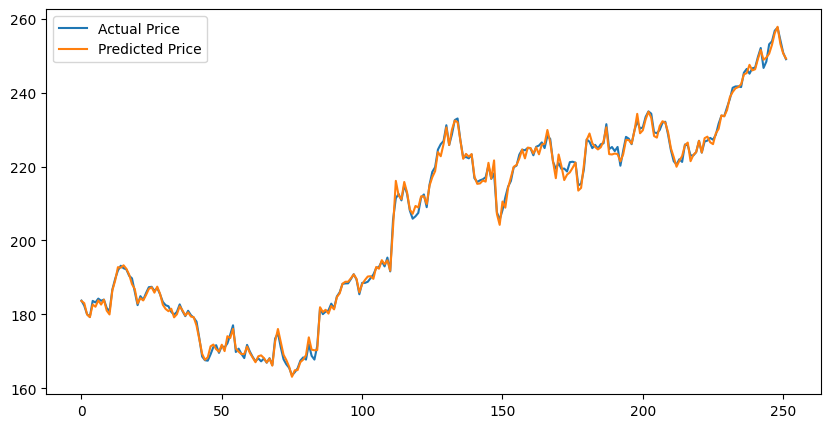

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.show()

#### Advanced Model-Random forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

C:\Users\PAVILION\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF R2: 0.06895813435909182


### Industry-level model-LSTM(deep learnings)
#### Data Scallig

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(stock[['Close']])

#### Create Sequences

In [18]:
X, y = [], []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i,0])
    y.append(scaled_data[i,0])

X,y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

### LSTM Model

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=32)

C:\Users\PAVILION\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 0.1252
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0028
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0012
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 8.6057e-04
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 8.7427e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 9.1981e-04
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 8.6552e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 7.8794e-04
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 8.2251e-04
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 7.9307e-04


In [20]:
# Convert predictions back to original scale
predicted_prices = scaler.inverse_transform(y_pred.reshape(-1, 1))
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Flatten arrays to 1D
predicted_prices = predicted_prices.flatten()
actual_prices = actual_prices.flatten()


AttributeError: 'DataFrame' object has no attribute 'reshape'